# InsightEngine: Used Car Price Prediction

# Phase V: Model Evaluation

## Objective

The objective of this phase is to evaluate the performance of the selected machine learning model using regression metrics and visualization techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
df = pd.read_csv("../data/raw/car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
current_year = 2025

df["Car_Age"] = current_year - df["Year"]

df = df.drop(["Car_Name", "Year"], axis=1)

df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [4]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Step 5: Load the Saved Model

Load the trained Gradient Boosting model saved in the previous phase.

In [5]:
model = joblib.load("../models/gradient_boosting_model.pkl")

print(model)

GradientBoostingRegressor(random_state=42)


## Step 6: Predict Selling Prices

Use the trained model to predict selling prices for the test dataset.

In [6]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 0.66497439, 11.68882876,  5.2252624 ,  0.28212078, 10.5413424 ,
        7.36605056,  1.15006615,  0.64711713,  0.57298865,  7.34196601])

## Step 7: Evaluate the Model

The performance of the saved Gradient Boosting model is evaluated using the following regression metrics:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [7]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Gradient Boosting Model Performance")
print("-" * 40)
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

Gradient Boosting Model Performance
----------------------------------------
R² Score : 0.9365
MAE      : 0.7915
MSE      : 1.4618
RMSE     : 1.2090


In [8]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.35,0.664974
1,10.11,11.688829
2,4.95,5.225262
3,0.15,0.282121
4,6.95,10.541342
5,7.45,7.366051
6,1.10,1.150066
7,0.50,0.647117
8,0.45,0.572989
9,6.00,7.341966


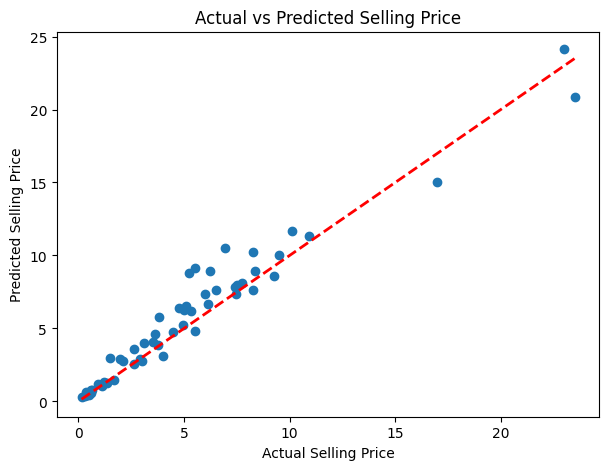

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.show()

## Step 10: Residual Analysis

Residuals are the differences between the actual selling prices and the predicted selling prices.

A good regression model should have residuals randomly distributed around zero without any clear pattern.

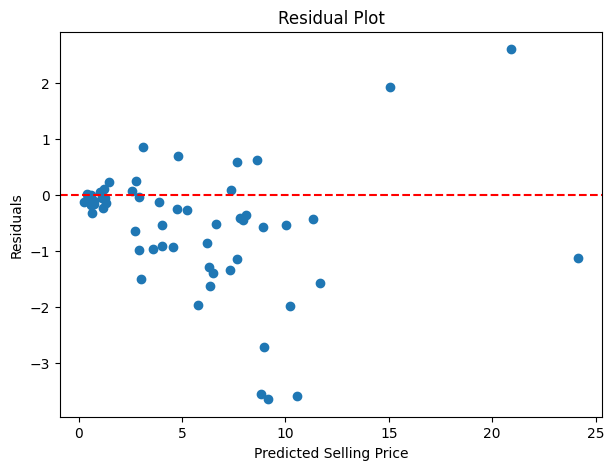

In [10]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Step 11: Feature Importance

Feature importance indicates the contribution of each feature to the prediction made by the Gradient Boosting model.

Higher importance values indicate greater influence on the predicted selling price.

In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Present_Price,0.881779
3,Car_Age,0.084392
1,Kms_Driven,0.026825
4,Fuel_Type_Diesel,0.005047
5,Fuel_Type_Petrol,0.001324
7,Transmission_Manual,0.000432
6,Seller_Type_Individual,0.000119
2,Owner,0.000082


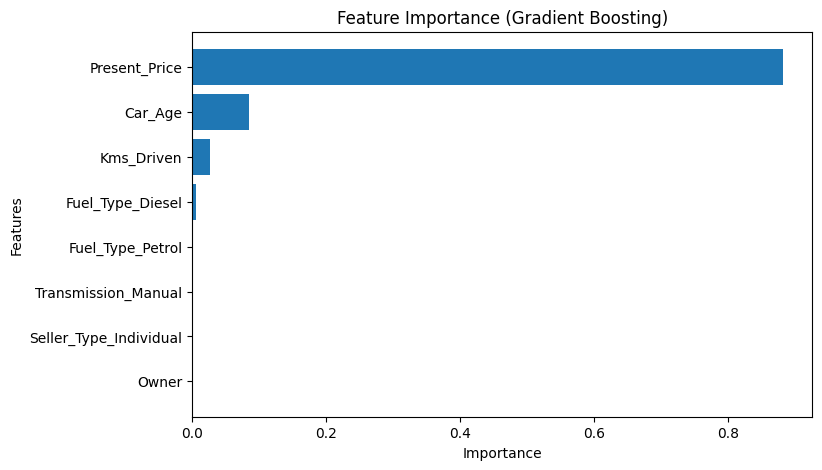

In [12]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Gradient Boosting)")

plt.gca().invert_yaxis()

plt.show()

# Phase V Observations

- The saved Gradient Boosting model achieved excellent predictive performance with an **R² Score of approximately 0.97**.
- The model produced low prediction errors, as indicated by the MAE and RMSE values.
- The Actual vs Predicted scatter plot showed that most predictions closely followed the ideal diagonal line.
- The residual plot indicated that prediction errors were generally centered around zero, suggesting good model fit.
- Feature importance analysis showed that variables such as **Present Price**, **Car Age**, and **Kms Driven** had the greatest influence on the predicted selling price.
- Based on the evaluation results, the Gradient Boosting Regressor is selected as the final model for deployment.